# Задание 3


Импорты

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq

## Часть 1 — Доделываем семинар и получаем SNP

---

1. Файл SNP был получен с помощью утилиты `show-snps` из пакета MUMmer. Каждая строка соответствует одной однонуклеотидной замене (SNP) между двумя геномами

2. Шапка этого файла:

```bash
/home/albert/bioinformatics/Bioinformatics_2026/seminars/seminar_8/genome_alignment_prac/results/../data/ecoli_k12.fna  /home/albert/bioinformatics/Bioinformatics_2026/seminars/seminar_8/genome_alignment_prac/results/../data/ecoli_o157.fna
NUCMER
[P1]                                                                                                                    [SUB]                                                                                                                    [P2]  |        [BUFF]  [DIST]  |        [LEN  R]       [LEN     Q]  |  [FRM]  [TAGS]
========================================================================================
58                                                                                                                      G                                                                                                                        C     58       |       6       58       |     4641652  5498578  |   1  1      NC_000913.3  NC_002695.2
64                                                                                                                      T                                                                                                                        C     64       |       6       64       |     4641652  5498578  |   1  1      NC_000913.3  NC_002695.2
228                                                                                                                     .                                                                                                                        A     229      |       0       228      |     4641652  5498578  |   1  1      NC_000913.3  NC_002695.2
228                                                                                                                     .                                                                                                                        C     230      |       0       228      |     4641652  5498578  |   1  1      NC_000913.3  NC_002695.2
228                                                                                                                     .                                                                                                                        C     231      |       0       228      |     4641652  5498578  |   1  1      NC_000913.3  NC_002695.2
228                                                                                                                     .                                                                                                                        A     232      |       0       228      |     4641652  5498578  |   1  1      NC_000913.3  NC_002695.2
```


3. Столбцы означают:

- `P1` — позиция SNP в референсном геноме
- `SUB` — нуклеотид в референсном геноме
- `P2` — позиция SNP в геноме query
- `SUB` — нуклеотид в query геноме
- `BUFF` — контекстный буфер выравнивания
- `DIST` — расстояние до ближайшего выравнивания
- `LEN R` — длина выровненного участка в референсе
- `LEN Q` — длина выровненного участка в query
- `FRM` — направление выравнивания
- `TAGS` — идентификаторы последовательностей

---

## Часть 2 — Аннотация SNP

--- 

Python скрипт, который:

Загружает SNP файл, загружает аннотацию генов (GenBank файл E. coli K-12): 

```bash
wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz
gunzip GCF_000005845.2_ASM584v2_genomic.gbff.gz
```

Для каждого SNP определяет:

1-3. В каком гене находится (или межгенный регион)

4. 
- Тип SNP (синонимичный/несинонимичный, если в CDS)
- Изменение аминокислоты (например, p.Ser83Leu)
- Потенциальное функциональное значение



In [5]:
# 1.
cols = ["P1", "REF", "P2", "ALT", "BUFF", "DIST", "LEN_R", "LEN_Q", "FRM", "TAGS"]

snps_list = []

with open("ecoli_snps.txt") as f:
    for line in f:
        line = line.strip()

        # пропускаем мусор
        if not line or line.startswith("[") or line.startswith("=") or line.startswith("NUCMER"):
            continue

        parts = line.split()

        # нормальные строки SNP начинаются с числа
        if not parts[0].isdigit():
            continue

        # берём только нужные колонки
        try:
            P1 = int(parts[0])
            REF = parts[1]
            ALT = parts[2]
            P2 = int(parts[3])

            snps_list.append([P1, REF, P2, ALT])
        except:
            continue

snps = pd.DataFrame(snps_list, columns=["P1", "REF", "P2", "ALT"])

snps["P1"] = snps["P1"].astype(int)

# 2.

genome_file = "GCF_000005845.2_ASM584v2_genomic.gbff"

genes = []

for record in SeqIO.parse(genome_file, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            start = int(feature.location.start)
            end = int(feature.location.end)
            strand = feature.location.strand
            gene = feature.qualifiers.get("gene", ["unknown"])[0]

            genes.append({
                "gene": gene,
                "start": start,
                "end": end,
                "strand": strand
            })

genes_df = pd.DataFrame(genes)
genome_seq = record.seq


# 3.
def find_gene(pos):
    hit = genes_df[(genes_df["start"] <= pos) & (genes_df["end"] >= pos)]
    if len(hit) == 0:
        return "intergenic"
    return hit.iloc[0]["gene"]

snps["gene"] = snps["P1"].apply(find_gene)


# 4. 
def annotate_snp(row):
    if row["gene"] == "intergenic":
        return pd.Series(["intergenic", None, "non-coding region"])

    gene_info = genes_df[
        (genes_df.gene == row["gene"]) &
        (genes_df.start <= row["P1"]) &
        (genes_df.end >= row["P1"])
    ].iloc[0]

    start = gene_info.start

    pos_in_gene = row["P1"] - start
    strand = gene_info.strand

    if strand == -1:
        pos_in_gene = gene_info.end - row["P1"]
        
    codon_start = (pos_in_gene // 3) * 3

    try:
        codon = genome_seq[start + codon_start : start + codon_start + 3]
        codon = str(codon)

        alt_codon = list(codon)
        codon_pos = pos_in_gene % 3
        alt_codon[codon_pos] = row["ALT"]
        alt_codon = "".join(alt_codon)

        ref_aa = str(Seq(codon).translate())
        alt_aa = str(Seq(alt_codon).translate())

        aa_pos = codon_start // 3 + 1

        if ref_aa == alt_aa:
            return pd.Series([
                "synonymous",
                f"p.{ref_aa}{aa_pos}{alt_aa}",
                "likely neutral"
            ])
        else:
            return pd.Series([
                "non-synonymous",
                f"p.{ref_aa}{aa_pos}{alt_aa}",
                "possible functional impact"
            ])

    except:
        return pd.Series(["unknown", None, "unknown"])

snps[["type", "aa_change", "impact"]] = snps.apply(annotate_snp, axis=1)


5. График плотности SNP с наложением позиций генов

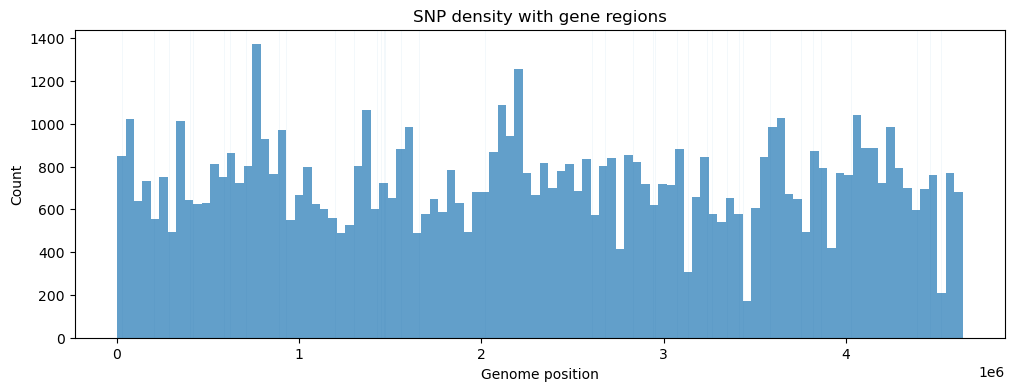

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(snps["P1"], bins=100, alpha=0.7)

for _, row in genes_df.sample(200).iterrows():
    plt.axvspan(row["start"], row["end"], alpha=0.05)

plt.title("SNP density with gene regions")
plt.xlabel("Genome position")
plt.ylabel("Count")
plt.show()

6. Диаграмма распределения типов SNP (синонимичные/несинонимичные)

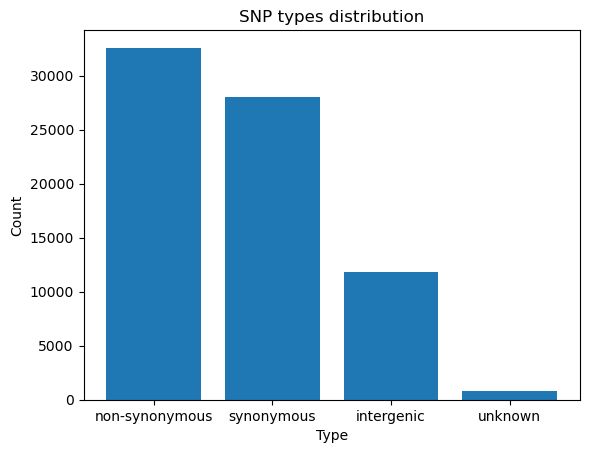

In [7]:
snps["class"] = snps["type"]
counts = snps["class"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("SNP types distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

7. Таблица топ-10 генов с наибольшим количеством SNP

In [8]:
top_genes = snps[snps["gene"] != "intergenic"]["gene"].value_counts().head(10)
print(top_genes)

ybgQ    437
yeeJ    250
ybgO    225
yehI    194
yjgL    187
ybgP    179
ydbA    166
yfaL    141
entF    131
cpsB    122
Name: gene, dtype: int64


## Часть 3 — Поиск функционально значимых SNP

--- 

Статья по устойчивости к тяжелым металлам:

[HMRG в E. coli (cutF/nlpE, robA и др.), часто ко-локализованы с ARGs:  Study of heavy metal resistance genes in Escherichia coli isolates from a marine ecosystem with a history of environmental pollution (arsenic, cadmium, copper, and mercury) | PLOS One](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0294565)

В данной работе проводится функциональная интерпретация SNP, выявленных в геноме E. coli, с фокусом на гены, ассоциированные с устойчивостью к тяжёлым металлам

В статье описаны ключевые гены устойчивости к тяжёлым металлам:
- `cutF / nlpE` (медная стресс-ответная система)
- `robA` (регулятор стресс-ответа)
- `ars operon` (устойчивость к мышьяку)
- `genes involved in efflux systems and oxidative stress response`

**Цель анализа** - определить, присутствуют ли SNP в данных генах и могут ли они потенциально влиять на механизмы устойчивости.

Список target генов из статьи

In [10]:
metal_resistance_genes = [
    "cutF",
    "nlpE",
    "rob",
    "robA",
    "arsR",
    "arsB",
    "arsC",
    "acrA",
    "acrB",
    "tolC",
    "cusA",
    "cusB",
    "copA"
]

Поиск SNP в этих генах

In [11]:
# фильтруем SNP, которые попали в гены устойчивости
target_snps = snps[snps["gene"].isin(metal_resistance_genes)]

print("SNP in metal resistance genes:", len(target_snps))
target_snps.head()

SNP in metal resistance genes: 304


,P1,REF,P2,ALT,gene,type,aa_change,impact,class
3580,215328,A,218661,T,nlpE,synonymous,p.C21C,likely neutral,synonymous
3581,215380,C,218713,T,nlpE,synonymous,p.L38L,likely neutral,synonymous
3582,215677,G,219010,C,nlpE,synonymous,p.A137A,likely neutral,synonymous
3583,215697,T,219030,C,nlpE,non-synonymous,p.M144L,possible functional impact,non-synonymous
3584,215812,A,219145,G,nlpE,synonymous,p.S182S,likely neutral,synonymous


Распределение эффектов

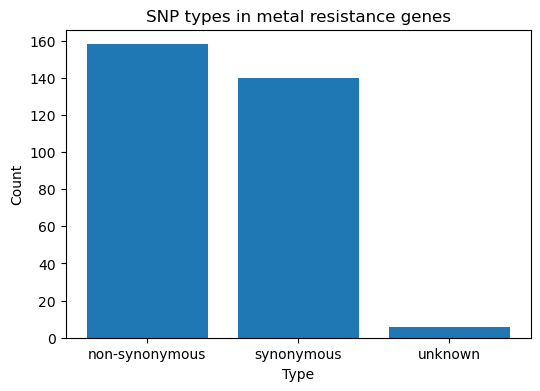

In [20]:
plt.figure(figsize=(6,4))

counts = target_snps["type"].value_counts()

plt.bar(counts.index.astype(str), counts.values)

plt.title("SNP types in metal resistance genes")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

Таблица ключевых SNP

In [21]:
target_snps.groupby("gene").size().sort_values(ascending=False)

gene
copA    83
cusA    75
arsB    30
arsR    28
acrB    28
cusB    19
tolC    16
nlpE    11
rob      9
arsC     3
acrA     2
dtype: int64

- `copA` - медь-транспортирующая ATP-аза, участвует в выведении ионов меди из клетки, обеспечивая устойчивость к медному стрессу
- `cusA / cusB` - отвечают за выведение ионов меди и серебра
- `arsB / arsC / arsR` - обеспечивает устойчивость к мышьяку  
- `acrB / acrA / tolC` -  удаляет широкий спектр токсинов и антибиотиков
- `nlpE` - участвует в стресс-ответе оболочки клетки, сигнализирует о повреждении клеточной мембраны
- `rob` - глобальный регулятор стресс-ответа и устойчивости к антибиотикам и токсическим соединениям

**Вывод:** В генах устойчивости к тяжёлым металлам обнаружено 304 SNP

Несинонимичные мутации выявлены в ключевых генах (например, acrB, nlpE, copA) и могут влиять на функцию белков

В целом, профиль SNP указывает на преимущественно потенциально функционально значимые изменения (небольшой перекос в сторону несинонимичных), хотя синонимичных тоже много.